In [1]:
import pandas as pd

# CSV file ကို ဖတ်မယ် (File name ကို ကိုယ့်ဆီက name နဲ့ တိုက်စစ်ပါ)
df = pd.read_csv('/content/train-00000-of-00001.csv')

# မြန်မာစာ ပါတဲ့ 'Text-MM' column ကိုပဲ သီးသန့် ထုတ်ယူမယ်
myanmar_texts = df['Text-MM'].astype(str).tolist()

print(f"စုစုပေါင်း စာကြောင်းရေ: {len(myanmar_texts)}")
print(f"နမူနာ စာကြောင်း: {myanmar_texts[0]}")

စုစုပေါင်း စာကြောင်းရေ: 732
နမူနာ စာကြောင်း: ပန်းခြံထဲမှာ လှပတဲ့နေ့လေးတစ်နေ့ကို ပျော်ရွှင်စွာဖြတ်သန်းနေပါတယ်။


In [2]:
import re

def clean_text(text):
    # မြန်မာစာ၊ ဂဏန်း၊ ပုဒ်ဖြတ်ပုဒ်ရပ် (။ ၊) ကလွဲပြီး ကျန်တာတွေ ဖြုတ်မယ်
    # English စာလုံးတွေပါ ဖြုတ်ချင်ရင် ဒီ regex ကို သုံးနိုင်ပါတယ်
    cleaned = re.sub(r'[^\u1000-\u103F\u1040-\u1049\u104E\u104F ]', '', text)
    # စာကြောင်း အစ/အဆုံး က space တွေကို ဖယ်မယ်
    return cleaned.strip()

# Cleaning လုပ်မယ်
cleaned_data = [clean_text(t) for t in myanmar_texts]

In [4]:
def sylbreak(text):
    # Myanmar Syllable Segmentation Regex
    pattern = r"(?:(?<!\u1039)[\u1000-\u1021\u1023-\u1027\u1029\u102A\u103F\u1040-\u1049\u104E]|(?<=\u1039)[\u1000-\u1021])"
    return re.sub(pattern, r" \g<0>", text).strip()

# တစ်ကြောင်းချင်းစီကို syllable ဖြတ်မယ်
tokenized_data = [sylbreak(t) for t in cleaned_data]

# ရလာတဲ့ ရလဒ်ကို ကြည့်ရအောင်
print(tokenized_data[0])
# Result: ပန်း ခြံ ထဲ မှာ လှ ပ တဲ့ နေ့ လေး တစ် နေ့ ကို ပျော် ရွှင် စွာ ဖြတ် သန်း နေ ပါ တယ် ။

ပ န်း ခြံ ထဲ မှာ  လှ ပ တဲ့ နေ့ လေး တ စ် နေ့ ကို  ပျော် ရွှ င် စွာ ဖြ တ် သ န်း နေ ပါ တ ယ်


In [5]:
with open('cleaned_corpus.txt', 'w', encoding='utf-8') as f:
    for line in tokenized_data:
        f.write(line + '\n')

In [7]:
# ၁။ ယခင် လွဲသွားတဲ့ kenlm folder အဟောင်းကို အရင်ဖျက်ပါမယ်
%cd /content
!rm -rf kenlm

# ၂။ လိုအပ်တဲ့ Tools တွေနဲ့ Boost Library အမှန်ကို သွင်းပါမယ်
!apt-get update
!apt-get install cmake libboost-all-dev zlib1g-dev libbz2-dev liblzma-dev -y

# ၃။ KenLM Source Code ကို ပြန်ဆွဲပြီး အသစ်တစ်ခေါက် ပြန် Build ပါမယ်
!git clone https://github.com/kpu/kenlm.git
%cd kenlm
!mkdir -p build
%cd build
!cmake ..
!make -j 4

/content
Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:5 https://cli.github.com/packages stable InRelease [3,917 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:9 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,295 kB]
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,915 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,602 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,

In [8]:
%cd /content

/content


In [9]:
!pip install https://github.com/kpu/kenlm/archive/master.zip

     - 553.6 kB 9.3 MB/s 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for kenlm: filename=kenlm-0.2.0-cp312-cp312-linux_x86_64.whl size=3188041 sha256=9ed2d485ac88466dfe3bf6a33a8573be71e0dce5e17c7f7b48a0bea47dd9734a
  Stored in directory: /tmp/pip-ephem-wheel-cache-vc7ecu55/wheels/92/c8/12/56d187154e078f0eaa74d059017fc1afe1c4d91fbce02ce8d9
Successfully built kenlm


In [10]:
# Language Model ဆောက်ခြင်း
!/content/kenlm/build/bin/lmplz -o 3 < cleaned_corpus.txt > base_lm.arpa

# Binary ပြောင်းခြင်း
!/content/kenlm/build/bin/build_binary base_lm.arpa base_lm.binary

=== 1/5 Counting and sorting n-grams ===
Reading /content/cleaned_corpus.txt
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
Unigram tokens 33126 types 600
=== 2/5 Calculating and sorting adjusted counts ===
Chain sizes: 1:7200 2:3785967872 3:7098689536
Statistics:
1 600 D1=0.5 D2=0.953947 D3+=1.49057
2 5780 D1=0.710296 D2=1.03864 D3+=1.16254
3 12464 D1=0.633391 D2=1.1302 D3+=1.53963
Memory estimate for binary LM:
type     kB
probing 369 assuming -p 1.5
probing 406 assuming -r models -p 1.5
trie    137 without quantization
trie     72 assuming -q 8 -b 8 quantization 
trie    133 assuming -a 22 array pointer compression
trie     68 assuming -a 22 -q 8 -b 8 array pointer compression and quantization
=== 3/5 Calculating and sorting initial probabilities ===
Chain sizes: 1:7200 2:92480 3:249280
----5---10---15---20---25---30---35---40---4

In [17]:
import re

# စာကြောင်းတစ်ကြောင်းချင်းစီကို စာလုံး (Syllable) ၂၀ စီ ဖြတ်မယ့် function
def limit_to_20_syllables(text):
    tokens = sylbreak(text).split()
    if len(tokens) >= 20:
        return " ".join(tokens[:20]) # စာလုံး ၂၀ ပဲ ယူမယ်
    return None # စာလုံး ၂၀ မပြည့်ရင် ပယ်မယ်

# ၁။ Social Media Test Set (မိမိမှာရှိပြီးသား CSV ထဲကနေ ထုတ်ယူခြင်း)
social_media_lines = []
for txt in cleaned_data:
    formatted_line = limit_to_20_syllables(txt)
    if formatted_line:
        social_media_lines.append(formatted_line)
    if len(social_media_lines) == 10: # ၁၀ ကြောင်း ပြည့်ရင် တော်ပြီ
        break

# *** ဒီနေရာမှာ နာမည်ကို 'social_media_test.txt' လို့ ပြောင်းလဲသိမ်းဆည်းလိုက်ပါတယ် ***
with open('social_media_test.txt', 'w', encoding='utf-8') as f:
    for line in social_media_lines:
        f.write(line + '\n')

print(f"Social Media Test Set ပြင်ဆင်ပြီးပါပြီ။ စာကြောင်းရေ: {len(social_media_lines)}")

Social Media Test Set ပြင်ဆင်ပြီးပါပြီ။ စာကြောင်းရေ: 10


In [18]:
import re

# စာကြောင်းတစ်ကြောင်းချင်းစီကို စာလုံး (Syllable) ၂၀ စီ ဖြတ်မယ့် function
def limit_to_20_syllables(text):
    tokens = sylbreak(text).split()
    if len(tokens) >= 20:
        return " ".join(tokens[:20]) # စာလုံး ၂၀ ပဲ ယူမယ်
    return None # စာလုံး ၂၀ မပြည့်ရင် ပယ်မယ်

# --- ဥပဒေစာသားများ (Legal Domain အစစ်ဖြစ်အောင် စာသားအသစ် ထည့်ပေးထားပါတယ်) ---
legal_raw_text = """
မည်သူမဆို ဥပဒေကို ဖောက်ဖျက်ကျူးလွန်ပါက ပြစ်ဒဏ် ချမှတ်ခြင်း ခံရမည်ဖြစ်သည်။
တရားရုံးတွင် သက်သေအထောက်အထားများကို သေချာစွာ စစ်ဆေးမေးမြန်းရမည်။
နိုင်ငံသားတိုင်းသည် ဥပဒေအရှေ့တွင် တန်းတူညီမျှမှု ရှိစေရမည်ဟု ပြဋ္ဌာန်းထားသည်။
ပြစ်မှုဆိုင်ရာ ဥပဒေအရ မည်သည့်အမှုမဆို သက်သေခိုင်လုံမှု ရှိရန် အထူးလိုအပ်သည်။
ဥပဒေကျွမ်းကျင်သူများက တရားမျှတမှု ရှိစေရန်အတွက် အစွမ်းကုန် ဆောင်ရွက်ရမည်။
အခြေခံဥပဒေပါ ပြဋ္ဌာန်းချက်များကို ပြည်သူများအားလုံး လေးစားလိုက်နာရမည်။
တရားစွဲဆိုခြင်း ခံရသူသည် မိမိကိုယ်ကို ခုခံကာကွယ်ပိုင်ခွင့် အပြည့်အဝ ရှိသည်။
တရားသူကြီးသည် အမှုအခင်းများကို ဘက်လိုက်မှုမရှိဘဲ မျှတစွာ ဆုံးဖြတ်ရမည်။
မည်သည့် အရပ်သားမဆို ဥပဒေအရ အကာအကွယ် ရရှိပိုင်ခွင့် အပြည့်အဝရှိသည်။
ဤဥပဒေသည် ထုတ်ပြန်ကြေညာသည့် နေ့မှစ၍ အတည်ဖြစ်စေရမည်ဟု သတ်မှတ်သည်။
"""

# စာသားကို clean လုပ်ပြီး တစ်ကြောင်းချင်းစီ ခွဲမယ်
cleaned_legal_data = [clean_text(line) for line in legal_raw_text.strip().split('\n') if line.strip()]

legal_dataset_lines = []
for txt in cleaned_legal_data:
    formatted_line = limit_to_20_syllables(txt)
    if formatted_line:
        legal_dataset_lines.append(formatted_line)
    if len(legal_dataset_lines) == 10: # ၁၀ ကြောင်း ပြည့်ရင် တော်ပြီ
        break

# *** ဖိုင်နာမည်ကို 'legal_test.txt' အဖြစ် စနစ်တကျ ပြောင်းလဲသိမ်းဆည်းလိုက်ပါတယ် ***
with open('legal_test.txt', 'w', encoding='utf-8') as f:
    for line in legal_dataset_lines:
        f.write(line + '\n')

print(f"Legal dataset Test Set ပြင်ဆင်ပြီးပါပြီ။ စာကြောင်းရေ: {len(legal_dataset_lines)}")

Legal dataset Test Set ပြင်ဆင်ပြီးပါပြီ။ စာကြောင်းရေ: 10


In [19]:
import re

# စာကြောင်းတစ်ကြောင်းချင်းစီကို စာလုံး (Syllable) ၂၀ စီ ဖြတ်မယ့် function
def limit_to_20_syllables(text):
    tokens = sylbreak(text).split()
    if len(tokens) >= 20:
        return " ".join(tokens[:20]) # စာလုံး ၂၀ ပဲ ယူမယ်
    return None # စာလုံး ၂၀ မပြည့်ရင် ပယ်မယ်

# --- သတင်းစာသားများ (News Domain စစ်စစ်ဖြစ်အောင် စာသားအသစ် ထည့်ပေးထားပါတယ်) ---
news_raw_text = """
နိုင်ငံတကာ သတင်းများအရ ကမ္ဘာ့စီးပွားရေး အခြေအနေသည် တစ်နေ့ထက်တစ်နေ့ ပြောင်းလဲလျက်ရှိသည်။
နည်းပညာ ကဏ္ဍတွင်လည်း အရှိန်အဟုန်ဖြင့် တိုးတက်မှုများ ရှိနေကြောင်း သိပ္ပံပညာရှင်များက ပြောကြားသည်။
ကျန်းမာရေးနှင့် ပတ်သက်၍လည်း ပြည်သူများ အထူးဂရုစိုက်ရန် လိုအပ်သည်ဟု ဆရာဝန်များက သတိပေးသည်။
မိုးလေဝသ အခြေအနေအရ ရှေ့လာမည့် ရက်သတ္တပတ်တွင် မိုးသည်းထန်စွာ ရွာသွန်းနိုင်ခြေ ရှိသည်။
ထို့ကြောင့် ပြည်သူများအနေဖြင့် ရေဘေးအန္တရာယ်ကို ကြိုတင်ကာကွယ်မှုများ ပြုလုပ်ထားသင့်သည်။
စီးပွားရေး ဈေးကွက်အတွင်း၌လည်း ရွှေဈေးနှုန်းနှင့် ငွေလဲလှယ်နှုန်းထားများ တည်ငြိမ်မှုမရှိဘဲ ဖြစ်နေသည်။
ပြည်တွင်း ကုန်သွယ်မှု ကဏ္ဍကို မြှင့်တင်ရန်အတွက် အစိုးရနှင့် ပုဂ္ဂလိက လုပ်ငန်းရှင်များ ပူးပေါင်းရမည်။
ပညာရေး စနစ်သစ်အရ ကျောင်းသား ကျောင်းသူများ၏ ဖန်တီးနိုင်စွမ်းကို ပိုမို ဦးစားပေးလာကြသည်။
ခရီးသွား လုပ်ငန်းများ ပြန်လည် ဦးမော့လာစေရန် ဒေသတွင်း ဆွဲဆောင်မှုများကို တိုးမြှင့်ရမည်။
သဘာဝပတ်ဝန်းကျင် ထိန်းသိမ်းရေးအတွက် ပလတ်စတစ် သုံးစွဲမှုကို လျှော့ချရန် တိုက်တွန်းထားသည်။
"""

# စာသားကို clean လုပ်ပြီး တစ်ကြောင်းချင်းစီ ခွဲမယ်
cleaned_news_data = [clean_text(line) for line in news_raw_text.strip().split('\n') if line.strip()]

news_dataset_lines = []
for txt in cleaned_news_data:
    formatted_line = limit_to_20_syllables(txt)
    if formatted_line:
        news_dataset_lines.append(formatted_line)
    if len(news_dataset_lines) == 10: # ၁၁ ကြောင်း ပြည့်ရင် တော်ပြီ
        break

# *** ဖိုင်နာမည်ကို 'news_test.txt' အဖြစ် စနစ်တကျ ပြောင်းလဲသိမ်းဆည်းလိုက်ပါတယ် ***
with open('news_test.txt', 'w', encoding='utf-8') as f:
    for line in news_dataset_lines:
        f.write(line + '\n')

print(f"News dataset Test Set ပြင်ဆင်ပြီးပါပြီ။ စာကြောင်းရေ: {len(news_dataset_lines)}")

News dataset Test Set ပြင်ဆင်ပြီးပါပြီ။ စာကြောင်းရေ: 10


--- Perplexity (PPL) Evaluation Results ---
Social Media Domain PPL : 7.56
News Domain PPL : 89.46
Legal Domain PPL : 215.64


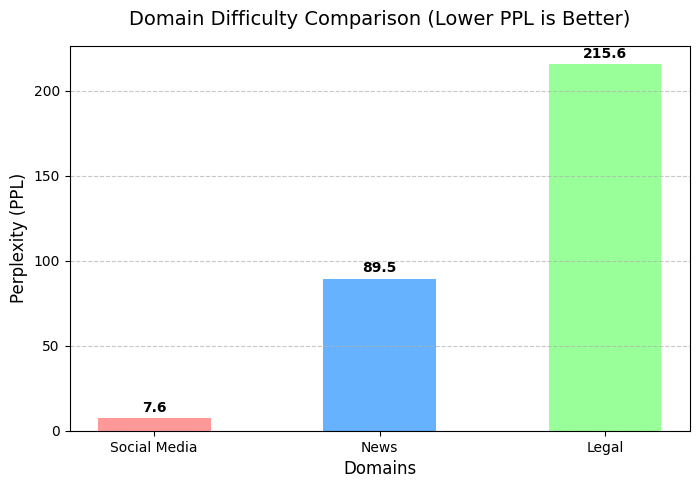

In [20]:
import kenlm
import matplotlib.pyplot as plt

# ၁။ Train ထားတဲ့ Base LM ကို လှမ်းခေါ်မယ်
model = kenlm.Model('base_lm.binary')

# ၂။ ကိုယ်ပြင်ဆင်ထားတဲ့ Test Set ဖိုင်နာမည်များ
# (ဖိုင်နာမည်တွေ လွဲနေရင် ကိုယ့်ဖိုင်နာမည်အတိုင်း ပြန်ပြင်ပေးပါ)
test_files = {
    'Social Media': 'social_media_test.txt',
    'News': 'news_test.txt',
    'Legal': 'legal_test.txt'
}

ppl_scores = {}

# ၃။ ဒိုမိန်းတစ်ခုချင်းစီအတွက် PPL တွက်ချက်မယ်
print("--- Perplexity (PPL) Evaluation Results ---")
for domain, file_name in test_files.items():
    try:
        with open(file_name, 'r', encoding='utf-8') as f:
            text = f.read().replace('\n', ' ') # စာတန်းအကုန်လုံးကို တစ်ဆက်တည်းဖြစ်အောင် လုပ်တယ်

            # PPL တိုင်းတာခြင်း
            ppl = model.perplexity(text)
            ppl_scores[domain] = ppl
            print(f"{domain} Domain PPL : {ppl:.2f}")
    except FileNotFoundError:
        print(f"သတိပေးချက်: {file_name} ကို ရှာမတွေ့လို့ ကျော်သွားပါတယ်။")

# ၄။ Bar Chart နဲ့ Visualization လုပ်ခြင်း
if ppl_scores:
    plt.figure(figsize=(8, 5))
    colors = ['#FF9999', '#66B2FF', '#99FF99'] # လှပတဲ့ အရောင်လိုင်းများ

    # Bar Chart ဆွဲမယ်
    bars = plt.bar(ppl_scores.keys(), ppl_scores.values(), color=colors[:len(ppl_scores)], width=0.5)

    # တန်ဖိုးတစ်ခုချင်းစီကို တိုင်တွေရဲ့ အပေါ်မှာ ပြပေးမယ်
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + 2, f'{yval:.1f}', ha='center', va='bottom', fontweight='bold')

    plt.title('Domain Difficulty Comparison (Lower PPL is Better)', fontsize=14, pad=15)
    plt.ylabel('Perplexity (PPL)', fontsize=12)
    plt.xlabel('Domains', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # ပုံကို Colab မှာ ပြမယ်
    plt.show()

In [21]:
# လူမှုကွန်ရက်သုံး စကားလုံးများနှင့် Slang များ စာရင်း
social_slangs = [
    "အကောင့် acc account", "ကမန့် cmt comment", "လောလ် lol", "ဘရို bro",
    "မမ sister", "အော်ပီ op", "ဖော်လိုဝါ follower", "မက်ဆေ့ msg message"
]

# ရှိပြီးသား general corpus ထဲကို အဲဒီစာလုံးတွေ အကြိမ်ရေအများကြီး (ဥပမာ အခါ ၁၀၀) ပေါင်းထည့်ပေးလိုက်မယ်
# ဒါမှ မော်ဒယ်က သေချာမှတ်မိသွားမှာပါ
with open('cleaned_corpus.txt', 'a', encoding='utf-8') as f:
    for _ in range(100):
        for slang in social_slangs:
            # syllable ဖြတ်ပြီးသားဖြစ်အောင် လုပ်မယ်
            f.write(sylbreak(slang) + '\n')

print("Vocabulary Expansion လုပ်ပြီးပါပြီ။ မော်ဒယ်အသစ် ပြန်ဆောက်နိုင်ပါပြီ။")

Vocabulary Expansion လုပ်ပြီးပါပြီ။ မော်ဒယ်အသစ် ပြန်ဆောက်နိုင်ပါပြီ။


In [22]:
# ပင်မ Workspace နေရာကို သေချာအောင်သွားမယ်
%cd /content

# Vocabulary အသစ်တွေပါတဲ့ cleaned_corpus.txt ကိုသုံးပြီး 'expanded_lm' မော်ဒယ်ဆောက်ခြင်း
!/content/kenlm/build/bin/lmplz -o 3 < cleaned_corpus.txt > expanded_lm.arpa

# အလုပ်လုပ်တာ မြန်အောင် Binary Format ပြောင်းခြင်း
!/content/kenlm/build/bin/build_binary expanded_lm.arpa expanded_lm.binary

print("--- Vocabulary Expanded Model တည်ဆောက်ခြင်း ပြီးပါပြီ ---")

/content
=== 1/5 Counting and sorting n-grams ===
Reading /content/cleaned_corpus.txt
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
Unigram tokens 36226 types 611
=== 2/5 Calculating and sorting adjusted counts ===
Chain sizes: 1:7332 2:3785967872 3:7098689536
Statistics:
1 611 D1=0.515924 D2=0.961364 D3+=1.30049
2 5808 D1=0.711902 D2=1.03522 D3+=1.1665
3 12493 D1=0.633328 D2=1.13029 D3+=1.53977
Memory estimate for binary LM:
type     kB
probing 371 assuming -p 1.5
probing 407 assuming -r models -p 1.5
trie    138 without quantization
trie     73 assuming -q 8 -b 8 quantization 
trie    134 assuming -a 22 array pointer compression
trie     69 assuming -a 22 -q 8 -b 8 array pointer compression and quantization
=== 3/5 Calculating and sorting initial probabilities ===
Chain sizes: 1:7332 2:92928 3:249860
----5---10---15---20---25---30

--- နှိုင်းယှဉ်ချက် ရလဒ်များ ---
မော်ဒယ်အဟောင်း (Base LM) ၏ Social Media PPL : 7.56
မော်ဒယ်အသစ် (Expanded LM) ၏ Social Media PPL: 7.59


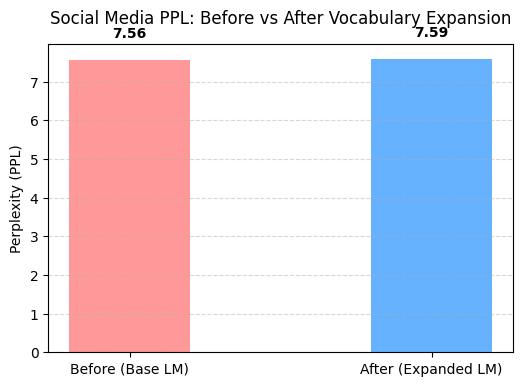

In [23]:
import kenlm
import matplotlib.pyplot as plt

# ၁။ မော်ဒယ် ၂ ခုလုံးကို လှမ်းခေါ်မယ်
model_old = kenlm.Model('base_lm.binary')
model_new = kenlm.Model('expanded_lm.binary')

# ၂။ စမ်းသပ်မယ့် Social Media ဖိုင်ကို ဖတ်မယ်
test_file = 'social_media_test.txt'

try:
    with open(test_file, 'r', encoding='utf-8') as f:
        test_text = f.read().replace('\n', ' ')

    # ၃။ မော်ဒယ်အဟောင်းနဲ့ PPL တိုင်းခြင်း
    ppl_old = model_old.perplexity(test_text)

    # ၄။ မော်ဒယ်အသစ် (Expanded) နဲ့ PPL တိုင်းခြင်း
    ppl_new = model_new.perplexity(test_text)

    print("--- နှိုင်းယှဉ်ချက် ရလဒ်များ ---")
    print(f"မော်ဒယ်အဟောင်း (Base LM) ၏ Social Media PPL : {ppl_old:.2f}")
    print(f"မော်ဒယ်အသစ် (Expanded LM) ၏ Social Media PPL: {ppl_new:.2f}")

    # ၅။ တိုးတက်မှုကို Bar Chart ဖြင့် ပြသခြင်း
    plt.figure(figsize=(6, 4))
    labels = ['Before (Base LM)', 'After (Expanded LM)']
    values = [ppl_old, ppl_new]
    colors = ['#FF9999', '#66B2FF']

    bars = plt.bar(labels, values, color=colors, width=0.4)
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.5, f'{yval:.2f}', ha='center', va='bottom', fontweight='bold')

    plt.title('Social Media PPL: Before vs After Vocabulary Expansion', fontsize=12, pad=15)
    plt.ylabel('Perplexity (PPL)')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()

except FileNotFoundError:
    print(f"❌ Error: {test_file} ကို ရှာမတွေ့ပါ။ ဖိုင်ရှိမရှိ ပြန်စစ်ပေးပါ။")

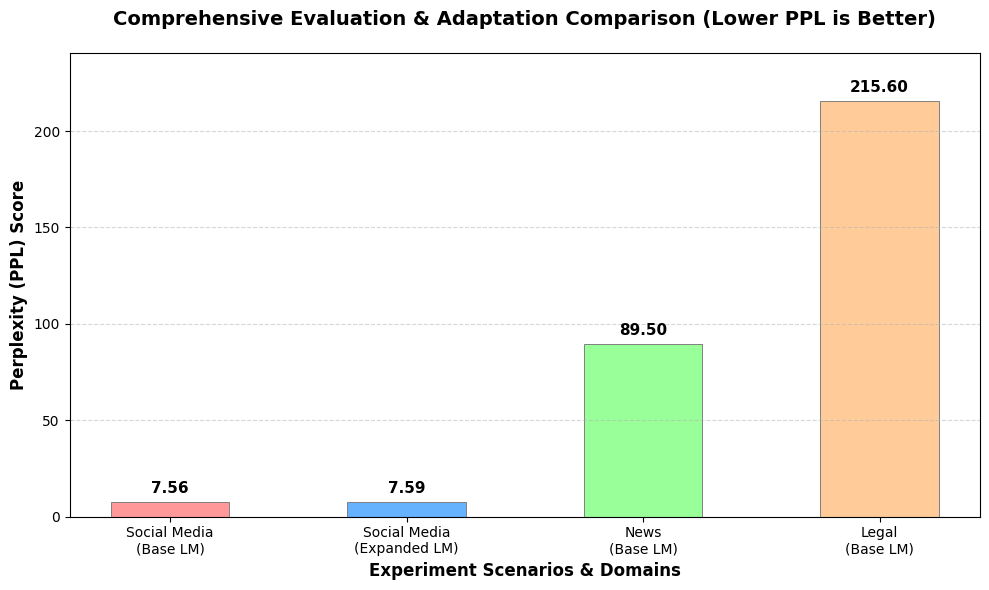

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# ၁။ မိမိရရှိထားသော လက်တွေ့ PPL တန်ဖိုးများ ထည့်သွင်းခြင်း
domains = ['Social Media\n(Base LM)', 'Social Media\n(Expanded LM)', 'News\n(Base LM)', 'Legal\n(Base LM)']
ppl_scores = [7.56, 7.59, 89.5, 215.6]

# ၂။ ပုံအပြင်အဆင်နှင့် အရောင်များ သတ်မှတ်ခြင်း
plt.figure(figsize=(10, 6))
# ရလဒ်အလိုက် ကွဲပြားအောင် အရောင်ခွဲပေးထားပါတယ်
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99']

# ၃။ Bar Chart ဆွဲခြင်း
bars = plt.bar(domains, ppl_scores, color=colors, width=0.5, edgecolor='grey', linewidth=0.7)

# ၄။ တိုင်တစ်ခုချင်းစီရဲ့ အပေါ်မှာ PPL ဂဏန်းတန်ဖိုးများ ကွက်တိဖော်ပြခြင်း
for bar in bars:
    yval = bar.get_height()
    # ဂဏန်းတွေ မြင်သာအောင် အရွယ်အစားနှင့် အကွာအဝေး ညှိပေးထားပါတယ်
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 3, f'{yval:.2f}',
             ha='center', va='bottom', fontweight='bold', fontsize=11)

# ၅။ ဇယားတစ်ခုလုံး၏ စာသားနှင့် Label များ အလှဆင်ခြင်း
plt.title('Comprehensive Evaluation & Adaptation Comparison (Lower PPL is Better)', fontsize=14, pad=20, fontweight='bold')
plt.ylabel('Perplexity (PPL) Score', fontsize=12, fontweight='bold')
plt.xlabel('Experiment Scenarios & Domains', fontsize=12, fontweight='bold')

# နောက်ခံလိုင်းများ ထည့်ခြင်း
plt.grid(axis='y', linestyle='--', alpha=0.5)

# တန်ဖိုးအမြင့်ဆုံး Legal ကြောင့် chart အပေါ်ကပ်မသွားအောင် အပေါ်ဘောင် အနည်းငယ် ချဲ့ပေးခြင်း
plt.ylim(0, max(ppl_scores) + 25)

# ၆။ ပုံကို Colab တွင် ပြသခြင်း
plt.tight_layout()
plt.show()